Executando Gridsearch
Fitting 10 folds for each of 72 candidates, totalling 720 fits

Melhores Hiperparâmetros Globais
activation: relu
alpha: 1e-05
hidden_layer_sizes: (10, 5)
learning_rate_init: 0.001

CV MAE Global: 11.327787

OCC = 0.2


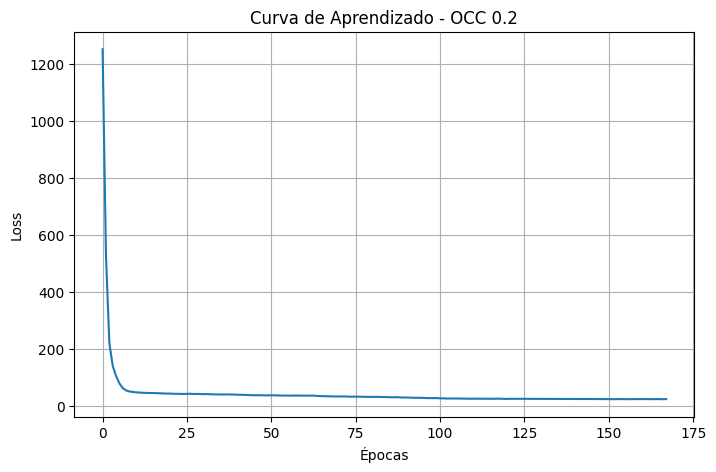

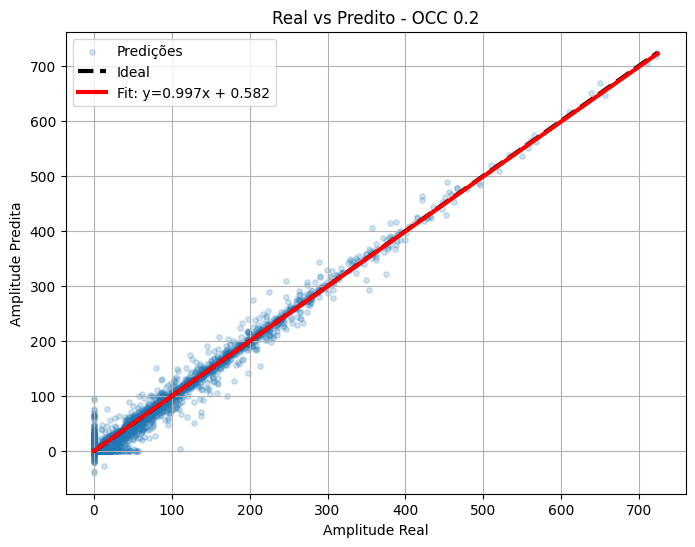

Test MAE: 2.519559
Test STD: 6.684309

OCC = 0.5


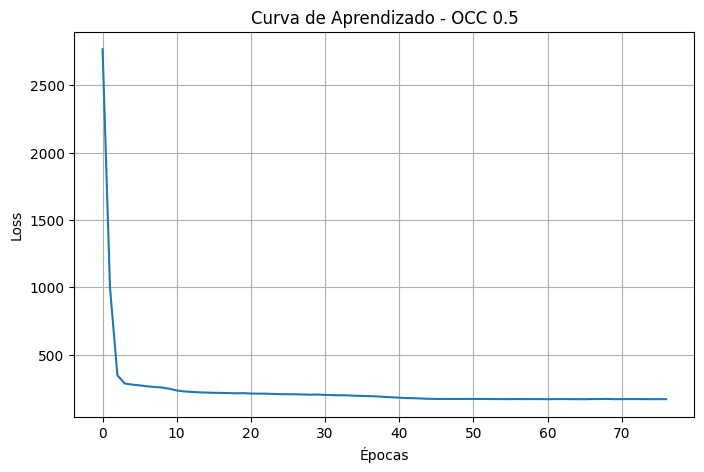

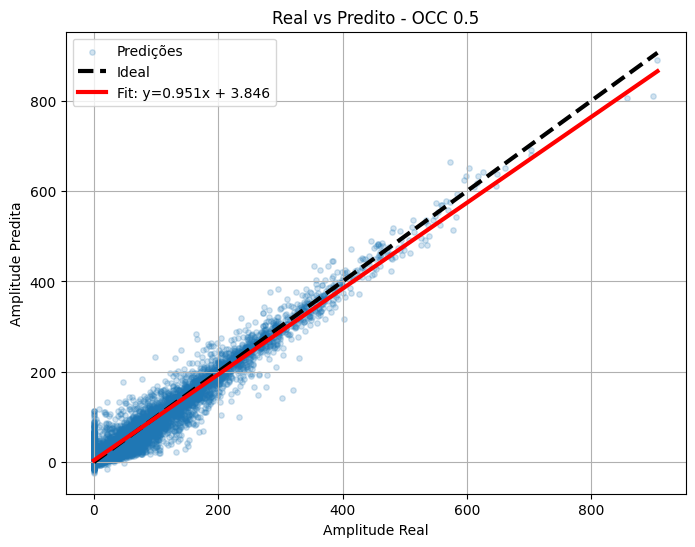

Test MAE: 11.738968
Test STD: 18.337212

OCC = 0.7


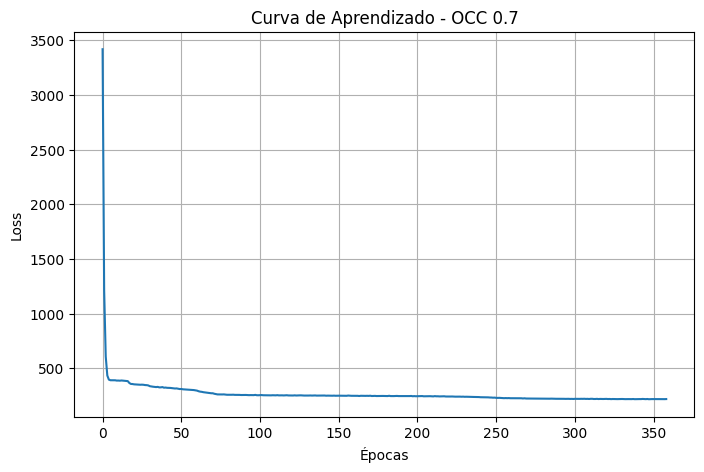

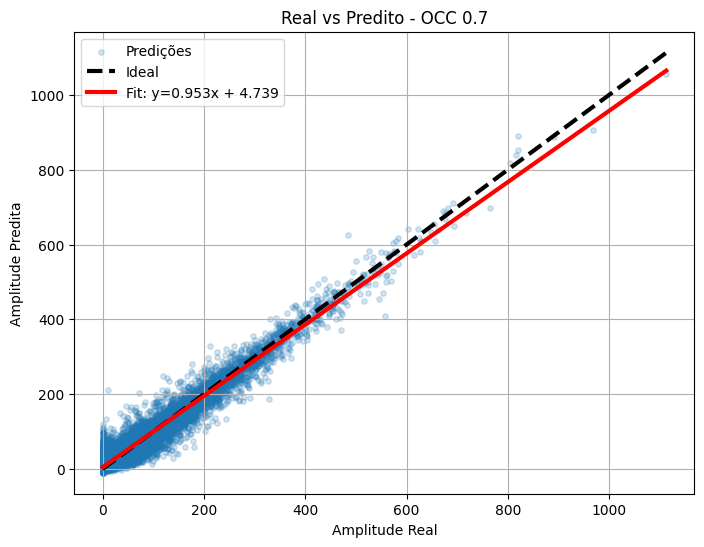

Test MAE: 14.131683
Test STD: 20.913832

OCC = 0.9


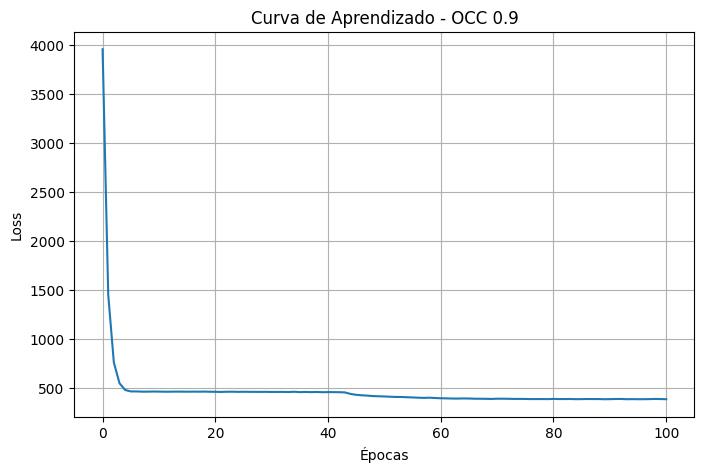

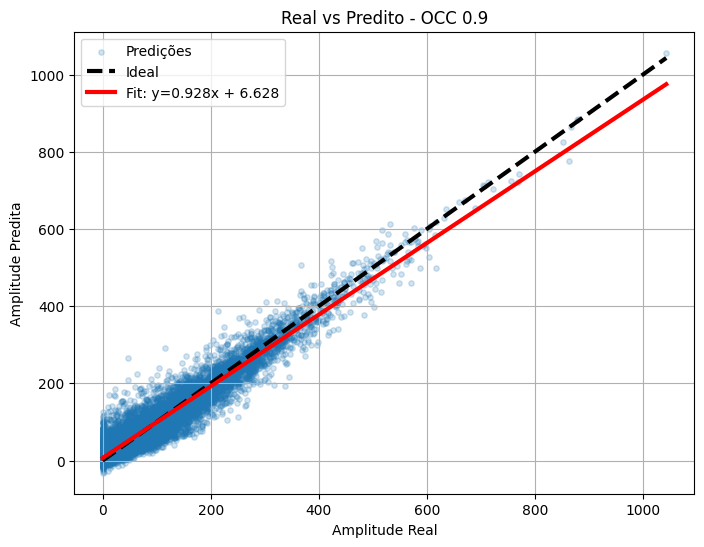

Test MAE: 20.227666
Test STD: 27.886753


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

import os

# Cria as pastas caso não existam
os.makedirs("resultados/graficos", exist_ok=True)
os.makedirs("resultados/stats", exist_ok=True)
os.makedirs("resultados/residuos", exist_ok=True)

# Arquivos de entrada


data = {
    '0.2': "C:\\Users\\Nat\\Desktop\\Projeto_Rede_Neural\\database\\data_occ0_2.csv",
    '0.5': "C:\\Users\\Nat\\Desktop\\Projeto_Rede_Neural\\database\\data_occ0_5.csv",
    '0.7': "C:\\Users\\Nat\\Desktop\\Projeto_Rede_Neural\\database\\data_occ0_7.csv",
    '0.9': "C:\\Users\\Nat\\Desktop\\Projeto_Rede_Neural\\database\\data_occ0_9.csv"
}

# Concatenar datasets
dfs = []

for path in data.values(): dfs.append(pd.read_csv(path))

df_total = pd.concat(dfs, ignore_index=True)

X_total = df_total[
    ['sample(0)', 'sample(1)', 'sample(2)',
     'sample(3)', 'sample(4)', 'sample(5)',
     'sample(6)']
].values
y_total = df_total['AmplitudeSample(4)'].values


# Modelo base
base_model = MLPRegressor(
    solver='adam',
    max_iter=1200,
    random_state=42
)


# Grid Search
param_grid = {
    'hidden_layer_sizes': [(5,),(7,),(10,),(15,),(7, 5),(10, 5)],
    'activation': ['relu','tanh'],
    'alpha': [1e-5,1e-4,1e-3],
    'learning_rate_init': [0.0001,0.001]
}

print('Executando Gridsearch')

X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_total,
    y_total,
    test_size=0.2,
    random_state=42
)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_global, y_train_global)

print("\nMelhores Hiperparâmetros Globais")

for k, v in grid.best_params_.items():
    print(f"{k}: {v}")

print(f"\nCV MAE Global: {-grid.best_score_:.6f}")

best_params = grid.best_params_

# Armazenamento
results = []
residuals_dict = {}

# Loop OCC
for occ, path in data.items():

    print(f"\n{'='*50}")
    print(f"OCC = {occ}")
    print(f"{'='*50}")

  
    # Leitura dos dados
    df = pd.read_csv(path)

    X = df[['sample(0)', 'sample(1)', 'sample(2)',
            'sample(3)', 'sample(4)', 'sample(5)',
            'sample(6)']].values

    y = df['AmplitudeSample(4)'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
  

    # Grid Search
   

    model = MLPRegressor(
        hidden_layer_sizes=best_params['hidden_layer_sizes'],
        activation=best_params['activation'],
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        solver='adam',
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    residuals = y_test - y_test_pred

    test_mae = np.mean(np.abs(residuals))
    test_std = np.std(residuals)

    residuals_dict[occ] = residuals
  

    # Curva de aprendizado
  

    plt.figure(figsize=(8, 5))

    plt.plot(model.loss_curve_)

    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title(f'Curva de Aprendizado - OCC {occ}')
    plt.grid(True)

    plt.savefig(
        f'curva_aprendizado_OCC_{occ}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

  
    # Real x Predito
  

    a, b = np.polyfit(y_test, y_test_pred, 1)

    x_fit = np.linspace(
        y_test.min(),
        y_test.max(),
        100
    )

    y_fit = a * x_fit + b

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_test_pred,
        alpha=0.2,
        s=15,
        label='Predições'
    )

    plt.plot(
        x_fit,
        x_fit,
        '--',
        color='black',
        linewidth=3,
        label='Ideal'
    )

    plt.plot(
        x_fit,
        y_fit,
        '-',
        color='red',
        linewidth=3,
        label=f'Fit: y={a:.3f}x + {b:.3f}'
    )

    plt.xlabel('Amplitude Real')
    plt.ylabel('Amplitude Predita')
    plt.title(f'Real vs Predito - OCC {occ}')

    plt.legend()
    plt.grid(True)

    plt.savefig(
        f'real_vs_predito_OCC_{occ}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()
  
    # Métricas
  

    results.append({
        'Occupancy': float(occ),

        'Global_hidden_layers':
            str(best_params['hidden_layer_sizes']),

        'Global_activation':
            best_params['activation'],

        'Global_alpha':
            best_params['alpha'],

        'Global_learning_rate':
            best_params['learning_rate_init'],

        'Global_CV_MAE':
            -grid.best_score_,

        'Test_MAE':
            test_mae,

        'Test_STD':
            test_std,

        'Epochs':
            model.n_iter_,

        'Final_Loss':
            model.loss_
    })

  
    print(f"Test MAE: {test_mae:.6f}")
    print(f"Test STD: {test_std:.6f}")



# Salvar métricas


stats_df = pd.DataFrame(results)

stats_df.to_csv(
    "rn_stats.csv",
    index=False
)


# Salvar resíduos

rn_residuals = pd.DataFrame(
    residuals_dict
)

rn_residuals.to_csv(
    "rn_residuals.csv",
    index=False
)

